In [160]:
from utils import DQN, ReplayBuffer, greedy_action, epsilon_greedy, update_target, loss
import time

import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import math
import numpy as np
import os

import gym
from gym.wrappers.monitoring.video_recorder import VideoRecorder
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib

In [161]:
NUM_RUNS = 10
epsilon_start = 0.5
epsilon_end = 0.25
epsilon_diff = epsilon_end - epsilon_start
epsilon_min = 50
epsilon_max = 300

Starting run 1 of 10
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 10
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 10
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 4 of 10
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 5 of 10
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 6 of 10
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 7 of 10
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 8 of 10
episode  50 / 300
episode  100 / 300
epis

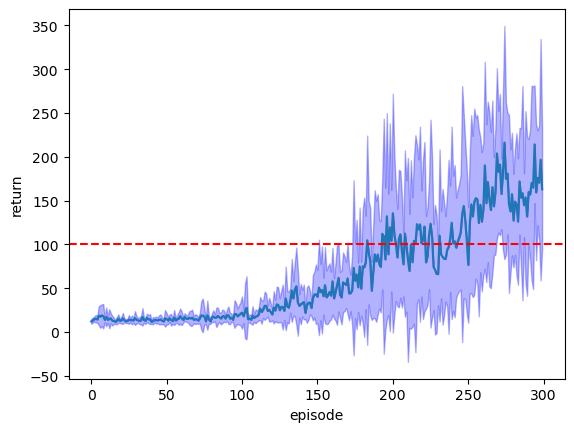

the execution took 628.9410619735718 seconds
avg per run execution time 62.894106197357175 seconds


In [70]:
t0 = time.time()
runs_results = []

cwd = os.getcwd()
video_dir = os.path.join(cwd, 'learned_dynamics')
if not os.path.isdir(video_dir):
    os.mkdir(video_dir)
video_file = os.path.join(video_dir, "learned_dynamics.mp4")

env = gym.make('CartPole-v1', render_mode="rgb_array")
video_recorder = VideoRecorder(env, video_file, enabled=False)
num_episodes = 300

policy_nets = []
target_nets = []

for run in range(NUM_RUNS):
    print(f"Starting run {run+1} of {NUM_RUNS}")
    layers = [4, 50, 2]
    policy_net = DQN([x for x in layers])
    target_net = DQN([x for x in layers])
    update_target(target_net, policy_net)
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters())
    memory = ReplayBuffer(500)

    steps_done = 0

    episode_durations = []

    for i_episode in range(num_episodes):
        if (i_episode+1) % 50 == 0:
            print("episode ", i_episode+1, "/", num_episodes)

        if i_episode < epsilon_min:
            epsilon = epsilon_start
        elif i_episode < epsilon_max:
            epsilon = epsilon_start + (i_episode - epsilon_min + 1) / (num_episodes - epsilon_min) * epsilon_diff
        else:
            epsilon = epsilon_end

        observation, info = env.reset()
        video_recorder.capture_frame()
        state = torch.tensor(observation).float()

        done = False
        terminated = False
        t = 0
        while not (done or terminated):

            # Select and perform an action
            action = epsilon_greedy(epsilon, policy_net, state)
            # observation, reward, done, terminated, info = env.step(action)
            observation, reward, done, terminated, info = env.step(action)
            video_recorder.capture_frame()
            reward = torch.tensor([reward])
            action = torch.tensor([action])
            next_state = torch.tensor(observation).reshape(-1).float()

            memory.push([state, action, next_state, reward, torch.tensor([done])])

            # Move to the next state
            state = next_state

            # Perform one step of the optimization (on the policy network)
            if len(memory.buffer) >= 1:
                transitions = memory.sample(8)
                state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions))
                # Compute loss
                mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                # Optimize the model
                optimizer.zero_grad()
                mse_loss.backward()
                optimizer.step()

            if done or terminated:
                episode_durations.append(t + 1)
            t += 1
        # Update the target network, copying all weights and biases in DQN
        if i_episode % 25 == 0:
            update_target(target_net, policy_net)
    runs_results.append(episode_durations)
    policy_nets.append(policy_net)
    target_nets.append(target_net)
print('Complete')
video_recorder.close()
video_recorder.enabled = False

# Plotting the learning curve
# Placeholder plot, you are free to modify it

def moving_avg(interval):
    window_size = 1
    window = np.ones(int(window_size)) / float(window_size)
    return np.convolve(interval, window, 'valid')

results = torch.tensor(runs_results)
means = moving_avg(results.float().mean(0).numpy())
stds = moving_avg(results.float().std(0).numpy())

plt.plot(np.arange(len(means)), means)
plt.ylabel("return")
plt.xlabel("episode")
plt.axhline(y = 100, color = 'r', linestyle = '--')
plt.fill_between(np.arange(len(means)), means, means+stds, alpha=0.3, color='b')
plt.fill_between(np.arange(len(means)), means, means-stds, alpha=0.3, color='b')

plt.show()
t1 = time.time()
total = t1 - t0
print(f'the execution took {total} seconds')
print(f'avg per run execution time {total / NUM_RUNS} seconds')

In [163]:
def avg(xs):
    return sum(xs) / len(xs)

total = t1 - t0
print(total / NUM_RUNS)

print(len(runs_results))
print(len(runs_results[0]))
xs = [int(avg(x)) for x in runs_results]
ys = int(avg(xs))
print(xs)
print(ys)


62.894106197357175
10
300
[57, 45, 54, 53, 79, 43, 87, 68, 66, 83]
63


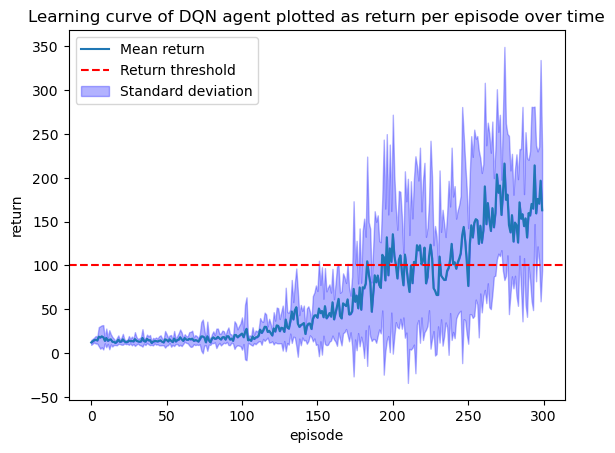

In [157]:
# Plotting the learning curve
# Placeholder plot, you are free to modify it

def moving_avg(interval):
    window_size = 1
    window = np.ones(int(window_size)) / float(window_size)
    return np.convolve(interval, window, 'valid')

results = torch.tensor(runs_results)
means = moving_avg(results.float().mean(0).numpy())
stds = moving_avg(results.float().std(0).numpy())

plt.plot(np.arange(len(means)), means, label='Mean return')
plt.ylabel("return")
plt.xlabel("episode")
plt.title("Learning curve of DQN agent plotted as return per episode over time")
plt.axhline(y = 100, color = 'r', linestyle = '--', label='Return threshold')
plt.fill_between(np.arange(len(means)), means, means+stds, alpha=0.3, color='b', label='Standard deviation')
plt.fill_between(np.arange(len(means)), means, means-stds, alpha=0.3, color='b')

plt.legend(loc='upper left')
# plt.savefig('/Users/piotrblaszyk/Downloads/rl-results-adam.png', dpi=1600)
plt.show()

## Choose best run out of the 10

In [146]:
avgs = np.array(xs)
best_ix = np.argmax(avgs)
policy_net = policy_nets[best_ix]
print(best_ix)

6


<Figure size 640x480 with 0 Axes>

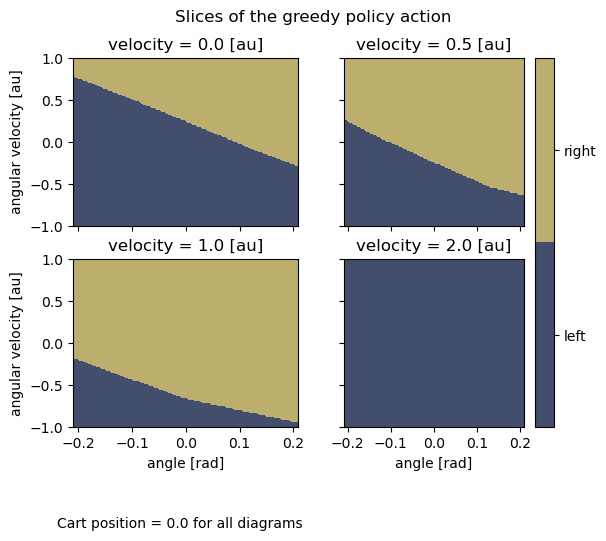

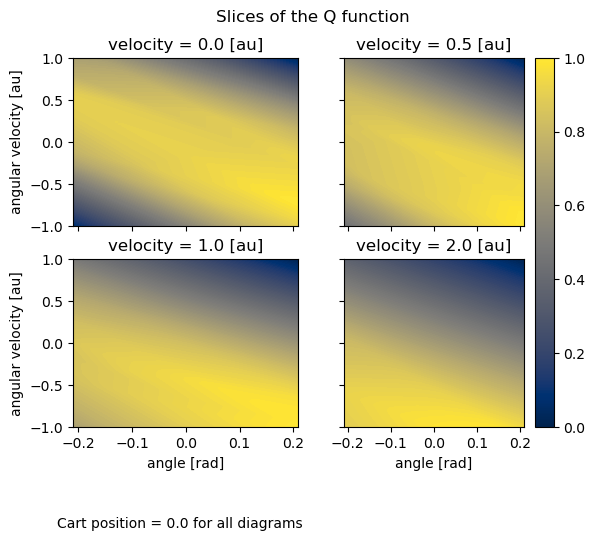

In [159]:
# Visualising the greedy Q-values for a stationary cart in the middle of the track
# 2D plot showing policy as a function of pole angle and angular velocity (omega)

# This plots the policy and Q values according to the network currently
# stored in the variable "policy_net"

# All visualisations provided here are placeholders and you can modify these plots

# Make sure to include appropriate labels and/or legends when presenting your plot

q = False    # whether q values or greedy policy is visualised

angle_range = .2095 # you may modify this range
omega_range = 1     # you may modify this range

angle_samples = 100
omega_samples = 100
angles = torch.linspace(angle_range, -angle_range, angle_samples)
omegas = torch.linspace(-omega_range, omega_range, omega_samples)

velocities = [0.0, 0.5, 1.0, 2.0]
greedy_q_array = torch.zeros((len(velocities), angle_samples, omega_samples))
policy_array = torch.zeros((len(velocities), angle_samples, omega_samples))

for k in range(len(velocities)):
    for i, angle in enumerate(angles):
        for j, omega in enumerate(omegas):
            state = torch.tensor([0., velocities[k], angle, omega])
            with torch.no_grad():
                q_vals = policy_net(state)
                greedy_action = q_vals.argmax()
                greedy_q_array[k, i, j] = q_vals[greedy_action]
                policy_array[k, i, j] = greedy_action

fmt = matplotlib.ticker.FuncFormatter(lambda x, pos: 'left' if x < 0.5 else 'right')

arrs = [policy_array, greedy_q_array]
suptitles = ["Slices of the greedy policy action", "Slices of the Q function"]
short_title = ['policy', 'q-function']

for arr_ix in range(len(arrs)):
    plt.figure(arr_ix)
    fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
    fig.suptitle(suptitles[arr_ix])
    plt.figtext(x=0.1,y=-0.1,s="Cart position = 0.0 for all diagrams")

    for i in range(2):
        for j in range(2):
            k = 2 * i + j
            cur = axs[i, j]
            if arr_ix == 0:
                cur.contourf(angles, omegas, policy_array[k, :, :].T, cmap='cividis', levels=1)
            else:
                cur.contourf(angles, omegas, greedy_q_array[k, :, :].T, cmap='cividis', levels=100)
            cur.set_title(f'velocity = {velocities[k]} [au]')
            cur.set(xlabel='angle [rad]', ylabel='angular velocity [au]')
            cur.label_outer()

    if arr_ix == 0:
        fig.colorbar(matplotlib.cm.ScalarMappable(cmap='cividis'), boundaries=[0.0, 0.5, 1.0], ticks=[0.25, 0.75], format=fmt, ax=axs[:, 1])
    else:
        fig.colorbar(matplotlib.cm.ScalarMappable(cmap='cividis'), ax=axs[:, 1])

    plt.savefig(f'/Users/piotrblaszyk/Downloads/rl-dqn-{short_title[arr_ix]}-slices.png', dpi=1600)